In [1]:
import verde as vd
import harmonica as hm

In [27]:
import numpy as np
import xarray as xr
import os.path as op
import xrft
from matplotlib import colors, ticker
import matplotlib.pyplot as plt

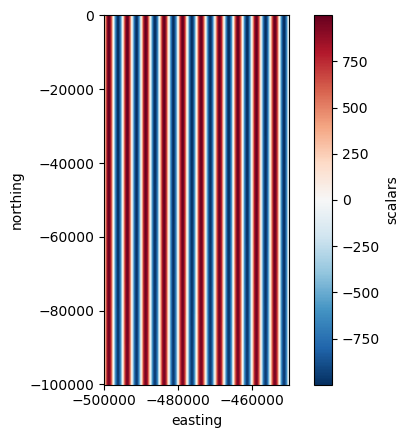

In [38]:
synth = vd.synthetic.CheckerBoard(
    amplitude=1000,
    region=(-500e3, -450e3, -100e3, 0),
    w_east=5e3,
    w_north=2000e3,
)
grid1 = synth.grid(shape=(500, 1000)).scalars
grid1.plot().axes.set_aspect('equal')

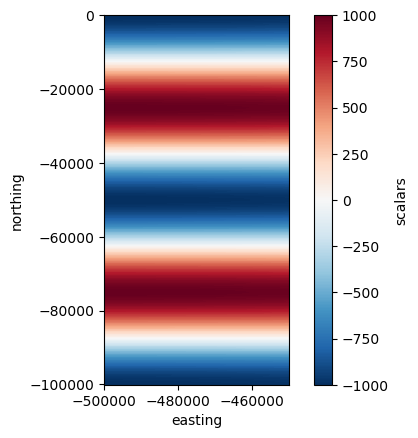

In [39]:
synth = vd.synthetic.CheckerBoard(
    amplitude=1000,
    region=(-500e3, -450e3, -100e3, 0),
    w_east=2000e3,
    w_north=50e3,
)
grid2 = synth.grid(shape=(500, 1000)).scalars
grid2.plot().axes.set_aspect('equal')

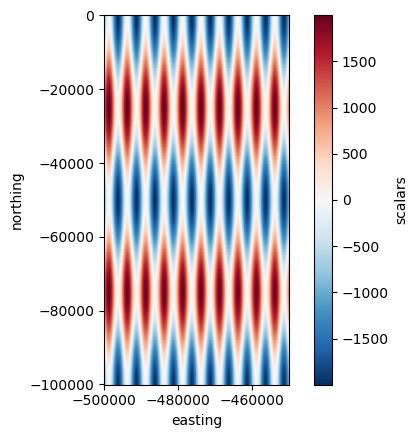

In [40]:
grid = grid1+grid2
grid.plot().axes.set_aspect('equal')

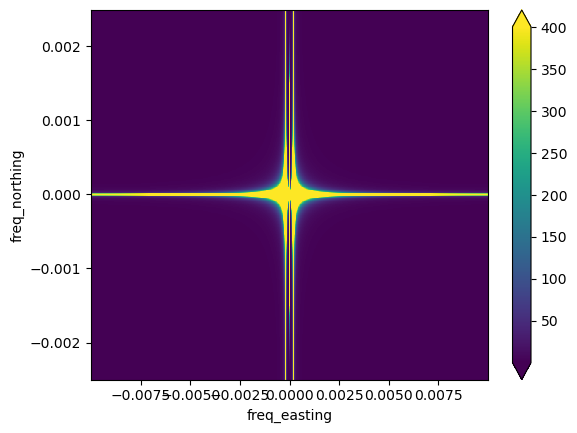

In [69]:
powerspec = xrft.power_spectrum(grid)
powerspec.plot(robust=True,)

Text(0.5, 0, 'cycles per km')

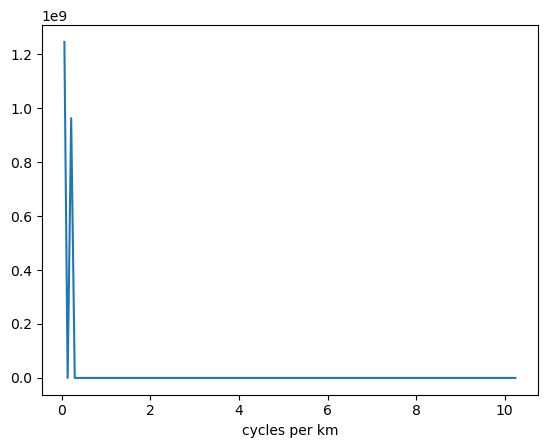

In [48]:
iso_powerspec = xrft.isotropic_power_spectrum(grid)
plt.plot(iso_powerspec.freq_r*1e3, iso_powerspec)
plt.xlabel('cycles per km')

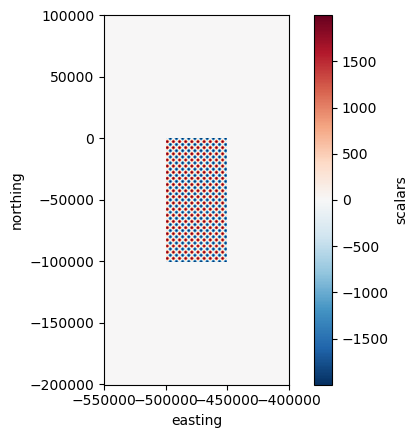

In [5]:
pad_width = {
    "easting": grid.easting.size,
    "northing": grid.northing.size,
}
import xrft

grid_padded = xrft.pad(grid, pad_width)
grid_padded.plot().axes.set_aspect('equal')

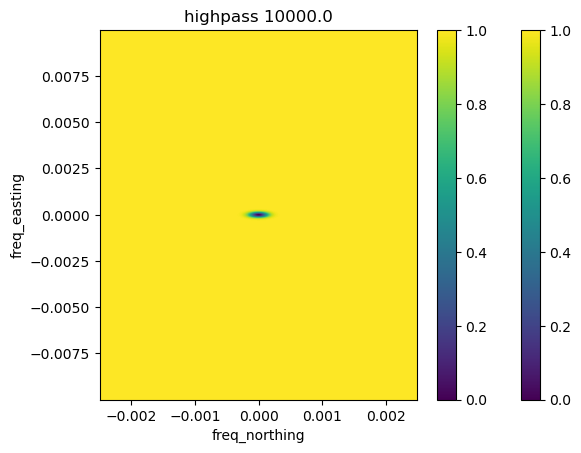

In [6]:
cutoff_wavelength = 10e3
grid_low_freqs = hm.gaussian_lowpass(
    grid_padded, wavelength=cutoff_wavelength
)
grid_high_freqs = hm.gaussian_highpass(
    grid_padded, wavelength=cutoff_wavelength
)

grid_low_freqs = xrft.unpad(grid_low_freqs, pad_width)
grid_high_freqs = xrft.unpad(grid_high_freqs, pad_width)

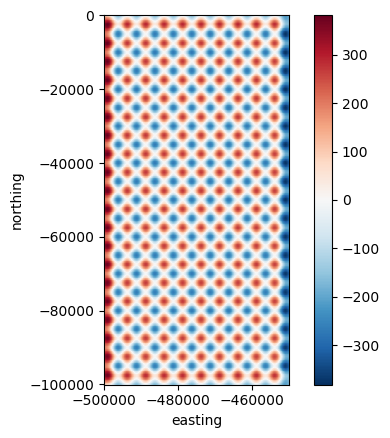

In [7]:
grid_low_freqs.plot().axes.set_aspect('equal')

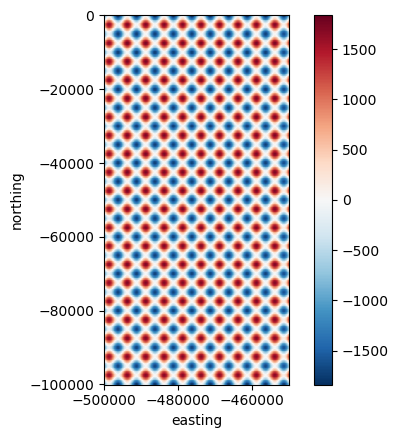

In [8]:
grid_high_freqs.plot().axes.set_aspect('equal')

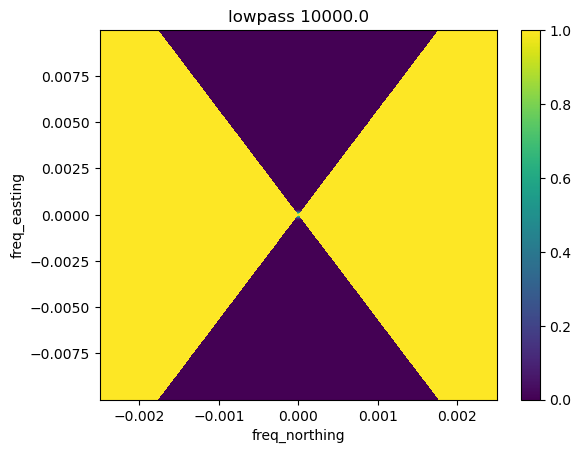

In [9]:
grid_low_freqs = hm.gaussian_lowpass(
    grid_padded, wavelength=cutoff_wavelength, angle_bounds=(-10,10)
)

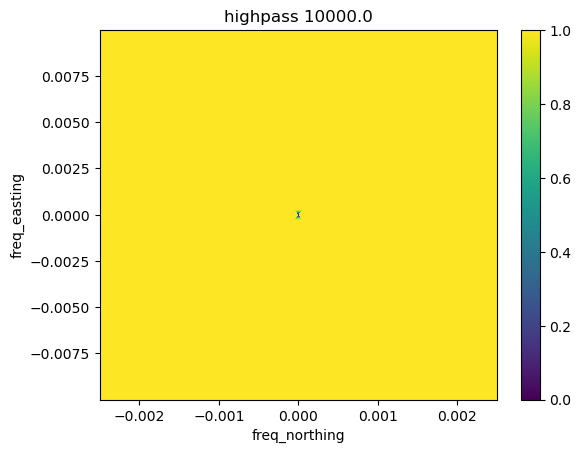

In [10]:
grid_high_freqs = hm.gaussian_highpass(
    grid_padded, wavelength=cutoff_wavelength, angle_bounds=(-10,10)
)

In [11]:
grid_low_freqs = xrft.unpad(grid_low_freqs, pad_width)
grid_high_freqs = xrft.unpad(grid_high_freqs, pad_width)

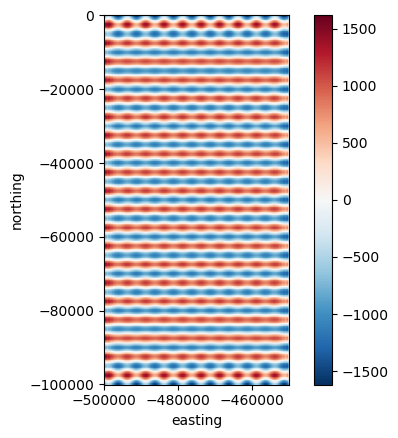

In [12]:
grid_low_freqs.plot().axes.set_aspect('equal')

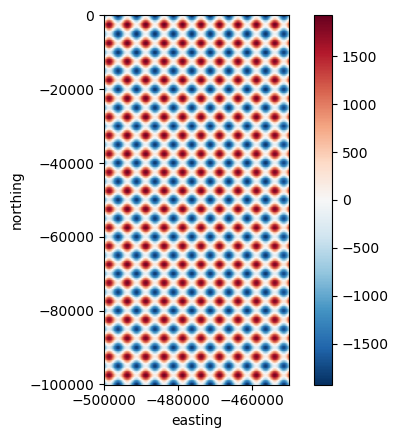

In [13]:
grid_high_freqs.plot().axes.set_aspect('equal')

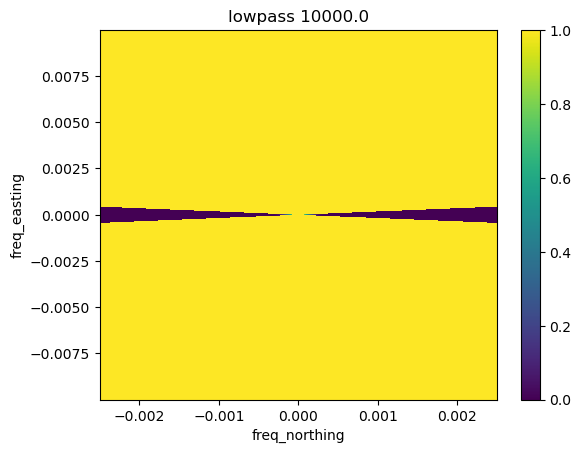

In [14]:
grid_low_freqs = hm.gaussian_lowpass(
    grid_padded, wavelength=cutoff_wavelength, angle_bounds=(80,100)
)
grid_low_freqs = xrft.unpad(grid_low_freqs, pad_width)

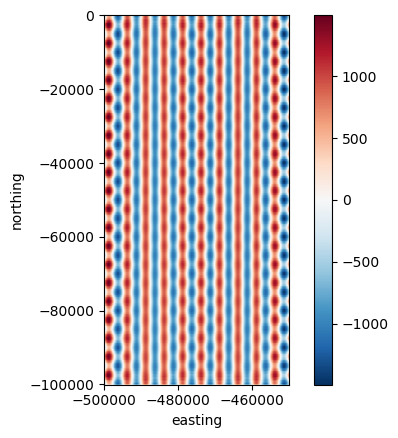

In [15]:
grid_low_freqs.plot().axes.set_aspect('equal')